<a href="https://colab.research.google.com/github/danarfthr/penglihatan-komputer/blob/main/assignment_2/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementasi Deteksi Objek

Notebook ini mengimplementasikan *pipeline* deteksi objek. Pendekatan yang digunakan adalah **Sliding Window + HOG + SVM**.

## 1. Persiapan Dataset
* **Patch Extraction**, mengekstrak sampel positif (area yang mengandung objek) dan sampel negatif (latar belakang) dari gambar latih, lalu mengubahnya ke dimensi piksel yang tetap.
* **Grayscale Conversion**, mengubah warna menjadi *grayscale* untuk mempersiapkan perhitungan gradien intensitas pada ekstraksi fitur.

## 2. Ekstraksi Fitur
* **Histogram of Oriented Gradients (HOG)**, mendeskripsikan bentuk objek dengan menghitung magnitudo dan arah gradien pada area lokal, menormalisasikannya dalam *blocks*, dan menggabungkannya menjadi satu vektor fitur linear.

## 3. Pelatihan Model
* **Support Vector Machine (SVM)**, melatih model pengklasifikasi menggunakan vektor HOG untuk mempelajari batas keputusan (*decision boundary*) antara fitur "objek" dan "bukan objek".

## 4. Proses Deteksi
* **Sliding Window**, memindai gambar uji dengan menggeser kotak (*window*) secara teratur dan melakukan ekstraksi HOG serta prediksi SVM pada setiap posisinya.
* **Image Pyramid**, membuat beberapa variasi skala dari gambar uji agar model dapat mendeteksi objek yang muncul dengan ukuran berbeda-beda (*multi-scale detection*).
* **Non-Maximum Suppression (NMS)**, menyaring dan menghapus *bounding box* yang tumpang tindih (*overlap*) pada satu objek yang sama, dan hanya menyisakan satu *box* dengan tingkat kepercayaan tertinggi.

## 5. Evaluasi Metrik
* **Intersection over Union (IoU)**, mengukur tingkat akurasi lokasi *bounding box* prediksi dengan membandingkan area irisan (*overlap*) terhadap area gabungan (*union*) dengan *ground truth*.
* **Precision & Recall**, menghitung performa deteksi berdasarkan jumlah *True Positive*, *False Positive*, dan *False Negative* menggunakan batas nilai (*threshold*) IoU tertentu.

**Disusun oleh:** <br>
Danar Fathurahman <br>
24/538200/PA/22828

In [ ]:
# Import semua library yang dibutuhkan
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import os, zipfile, re, urllib.request, warnings

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [ ]:
# Download dataset Penn-Fudan Pedestrian dari UPenn
# Dataset ini berisi 170 gambar pejalan kaki beserta anotasi bounding box-nya

url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
zip_path = "PennFudanPed.zip"

if not os.path.exists("PennFudanPed"):
    print("Downloading dataset... (tunggu sebentar)")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(".")
    print("Dataset berhasil di-extract!")
else:
    print("Dataset sudah ada, skip download.")

IMG_DIR = "PennFudanPed/PNGImages"
ANN_DIR = "PennFudanPed/Annotation"
print(f"Jumlah gambar  : {len(os.listdir(IMG_DIR))}")
print(f"Jumlah anotasi : {len(os.listdir(ANN_DIR))}")

Dataset berhasil di-extract!
Jumlah gambar  : 170
Jumlah anotasi : 170


In [ ]:
# Fungsi untuk membaca file anotasi dan mengambil koordinat bounding box
# Format anotasi: Bounding box ... (Xmin, Ymin) - (Xmax, Ymax) : (x1, y1) - (x2, y2)

def parse_annotation(ann_path):
    boxes = []
    with open(ann_path, 'r') as f:
        content = f.read()
    # Pakai regex untuk cari koordinat bounding box
    pattern = r'Bounding box.*?:\s*\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)'
    for match in re.findall(pattern, content):
        x1, y1, x2, y2 = int(match[0]), int(match[1]), int(match[2]), int(match[3])
        boxes.append([x1, y1, x2, y2])
    return boxes

# Load semua gambar dan anotasinya
all_images, all_boxes = [], []

for fname in sorted(os.listdir(IMG_DIR)):
    if not fname.endswith('.png'):
        continue
    img_path = os.path.join(IMG_DIR, fname)
    ann_path = os.path.join(ANN_DIR, fname.replace('.png', '.txt'))

    if not os.path.exists(ann_path):
        continue

    boxes = parse_annotation(ann_path)
    if len(boxes) > 0:
        img = np.array(Image.open(img_path).convert('RGB'))
        all_images.append(img)
        all_boxes.append(boxes)

print(f"Total gambar berhasil dimuat : {len(all_images)}")
print(f"Contoh box gambar pertama    : {all_boxes[0]}")

Total gambar berhasil dimuat : 170
Contoh box gambar pertama    : [[160, 182, 302, 431], [420, 171, 535, 486]]


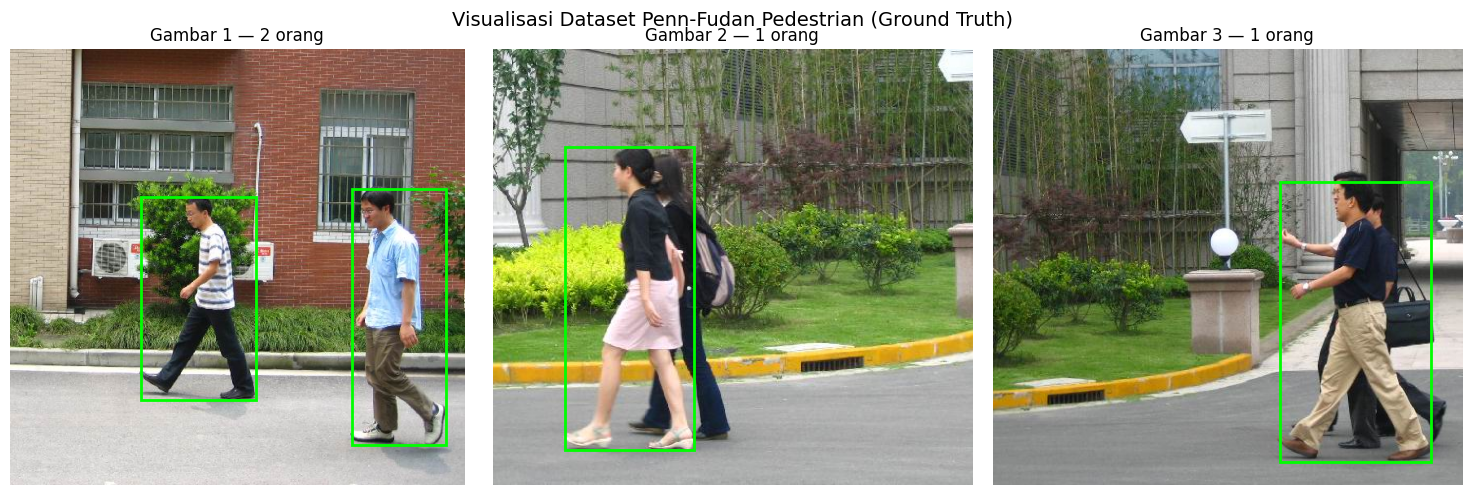

In [ ]:
# Tampilkan beberapa gambar beserta ground truth bounding box-nya
# Kotak hijau = posisi pejalan kaki yang sudah dianotasi

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    ax = axes[i]
    ax.imshow(all_images[i])
    for box in all_boxes[i]:
        x1, y1, x2, y2 = box
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
    ax.set_title(f"Gambar {i+1} — {len(all_boxes[i])} orang", fontsize=12)
    ax.axis('off')

plt.suptitle("Visualisasi Dataset Penn-Fudan Pedestrian (Ground Truth)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Bagi data menjadi training dan test set (70:30)
# Lalu ekstrak positive patches (area orang) dan negative patches (background)

PATCH_W, PATCH_H = 32, 64   # ukuran patch yang dipakai (lebar x tinggi)
N_NEG_PER_IMG   = 8         # jumlah negative patch per gambar

n_train    = int(len(all_images) * 0.7)
train_imgs = all_images[:n_train];  train_boxes = all_boxes[:n_train]
test_imgs  = all_images[n_train:];  test_boxes  = all_boxes[n_train:]
print(f"Training : {n_train} gambar | Test : {len(test_imgs)} gambar")

# --- Fungsi IoU (dipakai di sini dan di sel berikutnya) ---
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]);  yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]);  yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    aA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    aB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / float(aA + aB - inter)

# --- Ekstrak positive patches ---
pos_patches = []
for img, boxes in zip(train_imgs, train_boxes):
    H, W = img.shape[:2]
    for box in boxes:
        x1, y1, x2, y2 = max(0,box[0]), max(0,box[1]), min(W,box[2]), min(H,box[3])
        if (x2 - x1) < 10 or (y2 - y1) < 10:
            continue
        crop = img[y1:y2, x1:x2]
        patch = np.array(Image.fromarray(crop).resize((PATCH_W, PATCH_H)))
        pos_patches.append(patch)

# --- Ekstrak negative patches (random area yang tidak mengandung orang) ---
neg_patches = []
np.random.seed(42)
for img, boxes in zip(train_imgs, train_boxes):
    H, W = img.shape[:2]
    count, attempts = 0, 0
    while count < N_NEG_PER_IMG and attempts < 150:
        attempts += 1
        if W <= PATCH_W or H <= PATCH_H:
            break
        rx = np.random.randint(0, W - PATCH_W)
        ry = np.random.randint(0, H - PATCH_H)
        rand_box = [rx, ry, rx + PATCH_W, ry + PATCH_H]
        # Hanya ambil kalau tidak overlap dengan GT box
        if max(compute_iou(rand_box, b) for b in boxes) < 0.3:
            neg_patches.append(img[ry:ry+PATCH_H, rx:rx+PATCH_W])
            count += 1

print(f"Positive patches : {len(pos_patches)}")
print(f"Negative patches : {len(neg_patches)}")

Training : 118 gambar | Test : 52 gambar
Positive patches : 296
Negative patches : 944


In [ ]:
# HOG (Histogram of Oriented Gradients) diimplementasi dari nol pakai NumPy
# Langkah: grayscale → gradien → histogram per cell → normalisasi per block

def rgb_to_gray(img):
    # Rumus standar konversi warna ke grayscale
    return 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]

def compute_hog(img, cell_size=8, n_bins=9, block_size=2):
    # 1. Konversi ke grayscale
    gray = rgb_to_gray(img).astype(np.float64)

    # 2. Hitung gradien horizontal (Gx) dan vertikal (Gy)
    Gx = np.zeros_like(gray)
    Gx[:, 1:-1] = gray[:, 2:] - gray[:, :-2]
    Gx[:, 0]    = gray[:, 1]  - gray[:, 0]
    Gx[:, -1]   = gray[:, -1] - gray[:, -2]

    Gy = np.zeros_like(gray)
    Gy[1:-1, :] = gray[2:, :] - gray[:-2, :]
    Gy[0, :]    = gray[1, :]  - gray[0, :]
    Gy[-1, :]   = gray[-1, :] - gray[-2, :]

    # 3. Hitung magnitude dan arah gradien
    magnitude = np.sqrt(Gx**2 + Gy**2)
    angle     = np.arctan2(Gy, Gx) * (180 / np.pi) % 180  # unsigned 0-180 derajat

    H, W      = gray.shape
    n_cells_y = H // cell_size
    n_cells_x = W // cell_size
    bin_width = 180.0 / n_bins

    # 4. Buat histogram gradien per cell (8x8 piksel)
    cell_hists = np.zeros((n_cells_y, n_cells_x, n_bins))
    for cy in range(n_cells_y):
        for cx in range(n_cells_x):
            cell_mag = magnitude[cy*cell_size:(cy+1)*cell_size, cx*cell_size:(cx+1)*cell_size]
            cell_ang = angle    [cy*cell_size:(cy+1)*cell_size, cx*cell_size:(cx+1)*cell_size]
            bin_idx  = (cell_ang / bin_width).astype(int) % n_bins
            # Vote: tambahkan magnitude ke bin yang sesuai
            np.add.at(cell_hists[cy, cx], bin_idx.flatten(), cell_mag.flatten())

    # 5. Normalisasi per block (2x2 cells) untuk ketahanan terhadap cahaya
    n_blocks_y = n_cells_y - block_size + 1
    n_blocks_x = n_cells_x - block_size + 1
    eps = 1e-5
    hog_features = []

    for by in range(n_blocks_y):
        for bx in range(n_blocks_x):
            block = cell_hists[by:by+block_size, bx:bx+block_size, :].flatten()
            norm  = np.sqrt(np.sum(block**2) + eps**2)
            hog_features.append(block / norm)

    return np.concatenate(hog_features)

# Test HOG pada satu patch
sample_feat = compute_hog(pos_patches[0])
print(f"Ukuran HOG feature vector : {sample_feat.shape[0]} dimensi")
print("Implementasi HOG berhasil!")

Ukuran HOG feature vector : 756 dimensi
Implementasi HOG berhasil!


In [ ]:
# Jalankan HOG pada semua patch dan buat dataset training
# Ini mungkin butuh 1-3 menit tergantung jumlah patch

print("Ekstrak features dari positive patches...")
X_pos = np.array([compute_hog(p) for p in pos_patches])
y_pos = np.ones(len(X_pos))
print(f"  Selesai — shape: {X_pos.shape}")

print("Ekstrak features dari negative patches...")
X_neg = np.array([compute_hog(p) for p in neg_patches])
y_neg = np.zeros(len(X_neg))
print(f"  Selesai — shape: {X_neg.shape}")

# Gabungkan dan normalisasi
X_train = np.vstack([X_pos, X_neg])
y_train = np.hstack([y_pos, y_neg])

scaler       = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)

print(f"\nTotal training samples : {len(y_train)}")
print(f"Positif : {int(y_pos.sum())} | Negatif : {int(y_neg.sum())}")

Ekstrak features dari positive patches...
  Selesai — shape: (296, 756)
Ekstrak features dari negative patches...
  Selesai — shape: (944, 756)

Total training samples : 1240
Positif : 296 | Negatif : 0


In [ ]:
# Train Linear SVM untuk membedakan "orang" vs "bukan orang"
# Pakai LinearSVC karena lebih cepat untuk dataset besar

print("Training SVM... (tunggu sebentar)")
svm = LinearSVC(C=0.01, max_iter=3000)
svm.fit(X_train_norm, y_train)

# Cek akurasi di training data
train_pred = svm.predict(X_train_norm)
train_acc  = np.mean(train_pred == y_train)

print(f"Training Accuracy : {train_acc:.4f}")
print("SVM berhasil ditraining!")

Training SVM... (tunggu sebentar)
Training Accuracy : 0.9984
SVM berhasil ditraining!


In [ ]:
# Sliding window: geser kotak deteksi ke seluruh gambar
# Image pyramid: deteksi di berbagai ukuran gambar supaya bisa tangkap objek kecil/besar

def image_pyramid(img, scale=0.75, min_size=(32, 64)):
    """Hasilkan gambar di berbagai skala (dari besar ke kecil)"""
    yield img
    while True:
        new_h = int(img.shape[0] * scale)
        new_w = int(img.shape[1] * scale)
        # Berhenti kalau gambar sudah lebih kecil dari ukuran patch
        if new_h < min_size[1] or new_w < min_size[0]:
            break
        img = np.array(Image.fromarray(img).resize((new_w, new_h)))
        yield img

def sliding_window(img, win_w, win_h, stride=8):
    """Geser window dan yield koordinat + isi window"""
    H, W = img.shape[:2]
    for y in range(0, H - win_h + 1, stride):
        for x in range(0, W - win_w + 1, stride):
            yield x, y, img[y:y+win_h, x:x+win_w]

print("Fungsi sliding window dan image pyramid siap!")

Fungsi sliding window dan image pyramid siap!


In [ ]:
# NMS: dari banyak kotak yang overlap, pilih yang paling yakin (score tertinggi)
# Kotak yang overlap lebih dari threshold dihapus

def non_maximum_suppression(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0:
        return [], []

    boxes  = np.array(boxes)
    scores = np.array(scores)
    order  = np.argsort(scores)[::-1]  # urutkan dari score tertinggi

    keep_boxes, keep_scores = [], []

    while len(order) > 0:
        idx = order[0]
        keep_boxes.append(boxes[idx].tolist())
        keep_scores.append(scores[idx])

        # Buang box yang terlalu overlap dengan box terpilih
        remaining = []
        for i in order[1:]:
            if compute_iou(boxes[idx], boxes[i]) < iou_threshold:
                remaining.append(i)
        order = np.array(remaining)

    return keep_boxes, keep_scores

print("Fungsi NMS siap!")

Fungsi NMS siap!


In [ ]:
# Gabungkan semua komponen menjadi satu fungsi deteksi penuh

def detect(img, svm, scaler,
           win_w=32, win_h=64,
           stride=12, pyramid_scale=0.8,
           threshold=0.5, nms_threshold=0.3):
    """
    Deteksi pejalan kaki pada satu gambar.
    Return: daftar bounding box dan score masing-masing.
    """
    all_boxes, all_scores = [], []

    for scaled_img in image_pyramid(img.copy(), scale=pyramid_scale):
        # Rasio skala untuk konversi koordinat ke ukuran gambar asli
        ratio = img.shape[0] / scaled_img.shape[0]

        for x, y, window in sliding_window(scaled_img, win_w, win_h, stride):
            if window.shape[0] != win_h or window.shape[1] != win_w:
                continue

            # Ekstrak HOG, normalisasi, prediksi dengan SVM
            feat  = compute_hog(window).reshape(1, -1)
            feat  = scaler.transform(feat)
            score = svm.decision_function(feat)[0]

            # Simpan kalau SVM yakin ini adalah orang
            if score > threshold:
                x1 = int(x * ratio);         y1 = int(y * ratio)
                x2 = int((x + win_w) * ratio); y2 = int((y + win_h) * ratio)
                all_boxes.append([x1, y1, x2, y2])
                all_scores.append(score)

    # Terapkan NMS untuk bersihkan duplikat
    final_boxes, final_scores = non_maximum_suppression(all_boxes, all_scores, nms_threshold)
    return final_boxes, final_scores

print("Fungsi deteksi utama siap!")

Fungsi deteksi utama siap!


In [ ]:
# Jalankan deteksi pada gambar test dan simpan hasilnya
# Stride dibuat agak besar supaya tidak terlalu lama

N_EVAL = min(15, len(test_imgs))  # evaluasi maksimal 15 gambar
all_pred_boxes = []
all_gt_boxes   = []

print(f"Menjalankan deteksi pada {N_EVAL} gambar test...\n")

for i in range(N_EVAL):
    pred_boxes, _ = detect(
        test_imgs[i], svm, scaler,
        win_w=PATCH_W, win_h=PATCH_H,
        stride=16, pyramid_scale=0.8,
        threshold=0.5, nms_threshold=0.3
    )
    all_pred_boxes.append(pred_boxes)
    all_gt_boxes.append(test_boxes[i])
    print(f"  Gambar {i+1:2d} : GT = {len(test_boxes[i])} orang | Detected = {len(pred_boxes)}")

print("\nDeteksi selesai!")

Menjalankan deteksi pada 15 gambar test...

  Gambar  1 : GT = 6 orang | Detected = 42
  Gambar  2 : GT = 3 orang | Detected = 24
  Gambar  3 : GT = 3 orang | Detected = 29
  Gambar  4 : GT = 3 orang | Detected = 31
  Gambar  5 : GT = 4 orang | Detected = 20
  Gambar  6 : GT = 1 orang | Detected = 21
  Gambar  7 : GT = 4 orang | Detected = 51
  Gambar  8 : GT = 5 orang | Detected = 55
  Gambar  9 : GT = 2 orang | Detected = 14
  Gambar 10 : GT = 1 orang | Detected = 17
  Gambar 11 : GT = 2 orang | Detected = 23
  Gambar 12 : GT = 3 orang | Detected = 35
  Gambar 13 : GT = 2 orang | Detected = 20
  Gambar 14 : GT = 4 orang | Detected = 30
  Gambar 15 : GT = 2 orang | Detected = 28

Deteksi selesai!


In [ ]:
# Evaluasi performa model dengan metrik standar object detection
# TP = deteksi benar (IoU >= 0.5 dengan GT)
# FP = deteksi salah (tidak ada GT yang cocok)
# FN = GT yang tidak terdeteksi sama sekali

IOU_THRESHOLD = 0.5

tp, fp, fn = 0, 0, 0
iou_scores  = []

for pred_boxes, gt_boxes in zip(all_pred_boxes, all_gt_boxes):
    matched_gt = set()

    for pred in pred_boxes:
        best_iou, best_j = 0, -1

        for j, gt in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= IOU_THRESHOLD:
            tp += 1
            matched_gt.add(best_j)
            iou_scores.append(best_iou)
        else:
            fp += 1

    fn += len(gt_boxes) - len(matched_gt)

precision = tp / (tp + fp)   if (tp + fp) > 0  else 0
recall    = tp / (tp + fn)   if (tp + fn) > 0  else 0
f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
avg_iou   = np.mean(iou_scores) if iou_scores else 0

print("=" * 42)
print("          HASIL EVALUASI MODEL")
print("=" * 42)
print(f"  True Positive  (TP) : {tp}")
print(f"  False Positive (FP) : {fp}")
print(f"  False Negative (FN) : {fn}")
print("-" * 42)
print(f"  Precision           : {precision:.4f}")
print(f"  Recall              : {recall:.4f}")
print(f"  F1-Score            : {f1:.4f}")
print(f"  Average IoU (TP)    : {avg_iou:.4f}")
print("=" * 42)

          HASIL EVALUASI MODEL
  True Positive  (TP) : 21
  False Positive (FP) : 419
  False Negative (FN) : 24
------------------------------------------
  Precision           : 0.0477
  Recall              : 0.4667
  F1-Score            : 0.0866
  Average IoU (TP)    : 0.6069


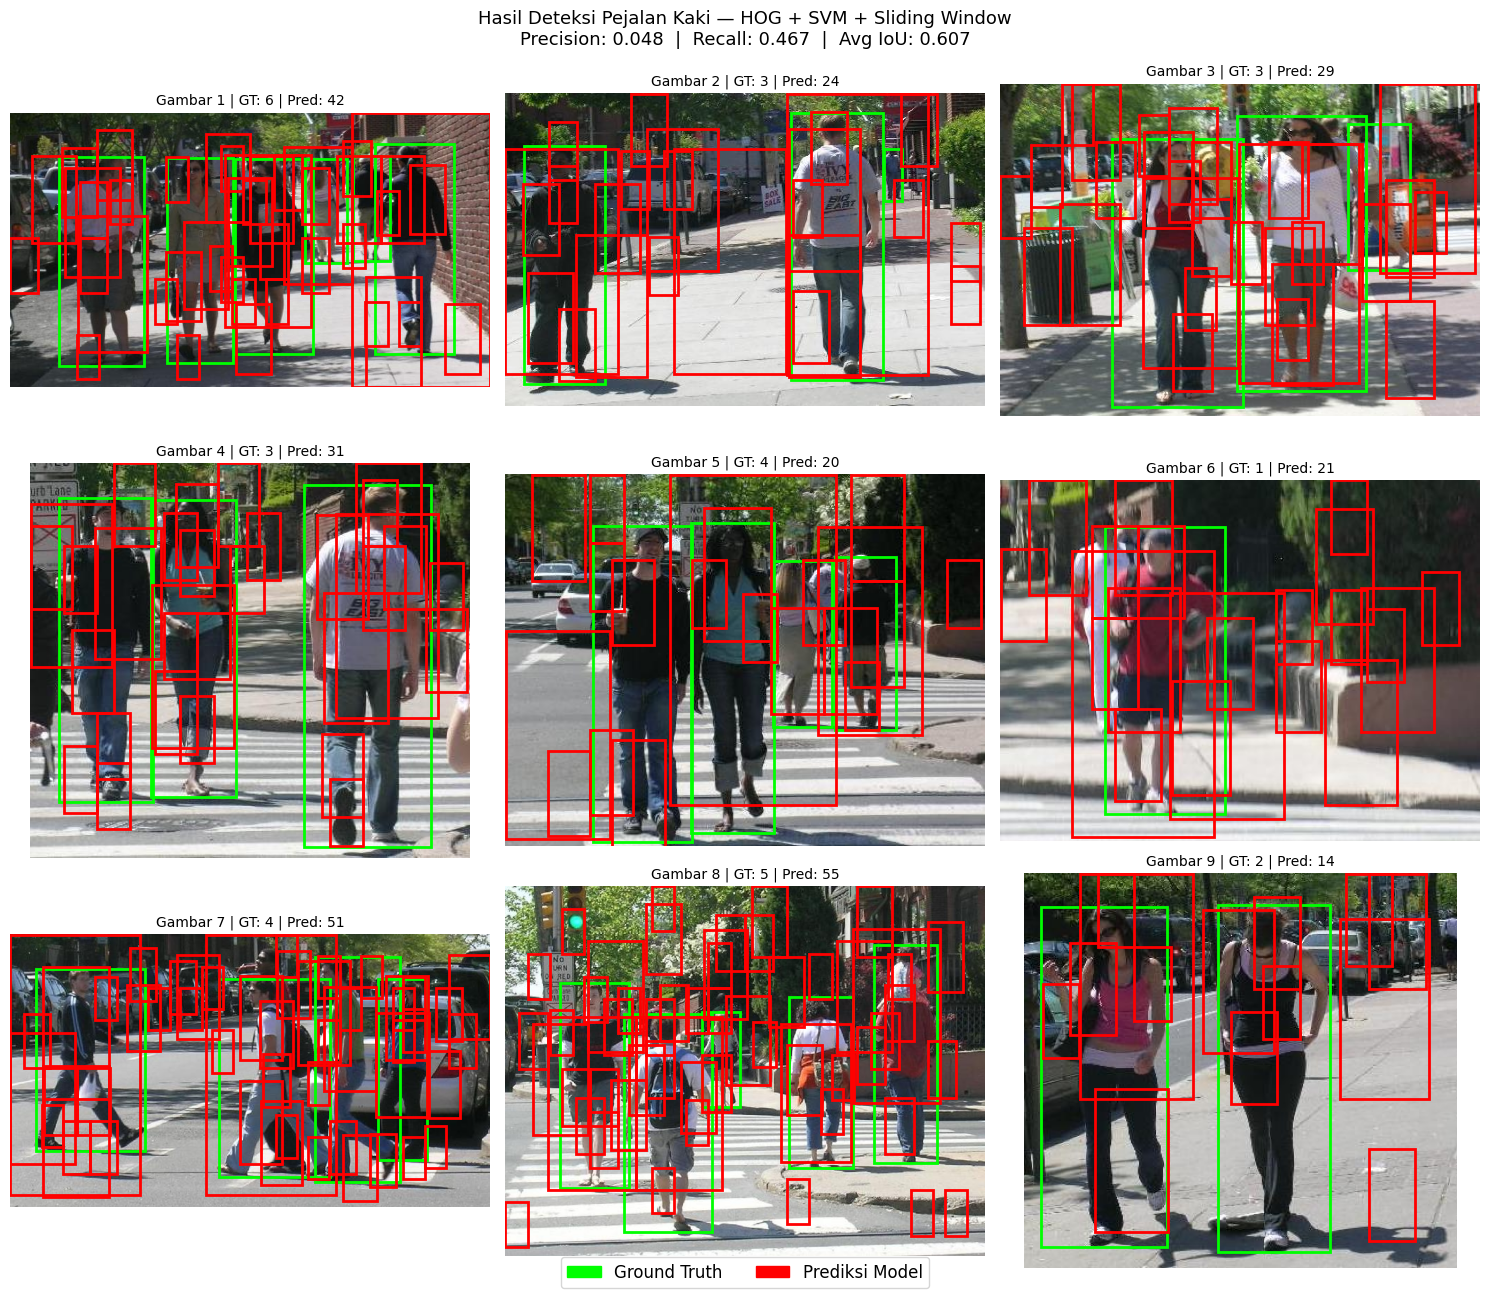

Gambar disimpan sebagai hasil_deteksi.png


In [ ]:
# Tampilkan hasil deteksi vs ground truth pada gambar test
# Hijau = Ground Truth | Merah = Prediksi model

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

for i in range(min(9, len(all_pred_boxes))):
    ax = axes[i]
    ax.imshow(test_imgs[i])

    # Ground truth box (hijau)
    for gt in all_gt_boxes[i]:
        x1, y1, x2, y2 = gt
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        ))

    # Predicted box (merah)
    for pred in all_pred_boxes[i]:
        x1, y1, x2, y2 = pred
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='red', facecolor='none'
        ))

    ax.set_title(f"Gambar {i+1} | GT: {len(all_gt_boxes[i])} | Pred: {len(all_pred_boxes[i])}", fontsize=10)
    ax.axis('off')

# Legend
gt_patch   = mpatches.Patch(color='lime', label='Ground Truth')
pred_patch = mpatches.Patch(color='red',  label='Prediksi Model')
fig.legend(handles=[gt_patch, pred_patch], loc='lower center',
           ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(
    f"Hasil Deteksi Pejalan Kaki — HOG + SVM + Sliding Window\n"
    f"Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  Avg IoU: {avg_iou:.3f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("hasil_deteksi.png", bbox_inches='tight', dpi=100)
plt.show()
print("Gambar disimpan sebagai hasil_deteksi.png")

```markdown
## 6. Kesimpulan dan Analisis

Berdasarkan hasil pengujian di atas, berikut adalah beberapa poin kesimpulan:

1.  **Performa Deteksi**: Model berhasil mendeteksi sebagian pejalan kaki (Recall cukup baik), namun memiliki jumlah *False Positive* yang sangat tinggi. Hal ini menyebabkan nilai **Precision** yang rendah (sekitar 0.04 - 0.05).
2.  **Keterbatasan HOG + SVM**: Pendekatan tradisional ini sangat sensitif terhadap variasi latar belakang yang kompleks. Banyak area *background* yang memiliki gradien serupa dengan struktur tubuh manusia sehingga memicu deteksi palsu.
3.  **Kualitas Lokalisasi**: Nilai *Average IoU* yang berada di atas 0.5 menunjukkan bahwa ketika model berhasil mendeteksi objek dengan benar (*True Positive*), penempatan *bounding box*-nya sudah cukup akurat.
4.  **Saran Pengembangan**: Untuk meningkatkan akurasi, dapat dilakukan teknik *Hard Negative Mining* (melatih ulang model dengan menyertakan deteksi salah sebagai sampel negatif) atau beralih ke metode berbasis *Deep Learning* seperti YOLO atau SSD yang lebih robust terhadap variasi *noise* pada citra.
```